In [18]:
# Import libraries here
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted

from category_encoders import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.simplefilter(action="ignore", category=FutureWarning)

In [19]:
#LOCAL WRANGLE
def wrangle():
    df = pd.read_csv("data/kavrepalanchok.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    #Multicollinearity Columns drop
    df.drop(columns=['count_floors_pre_eq'], inplace=True)

    #High Cardinality
    # df.drop(columns=['building_id'],inplace=True)


    return df

In [20]:
df = wrangle();
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,
87473,15,382,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1
87479,12,328,7,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,"Stone, mud mortar",1
87482,23,427,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1
87491,12,427,14,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1
87496,32,360,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",1


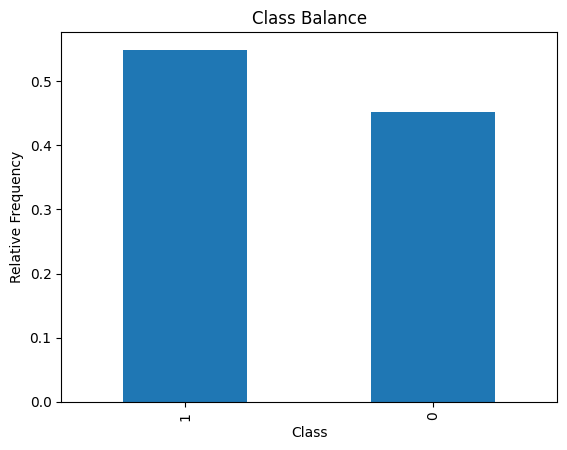

In [21]:
# Plot value counts of `"severe_damage"`
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar",xlabel="Class", ylabel="Relative Frequency", title="Class Balance"
)

# Don't delete the code below 👇
plt.show()

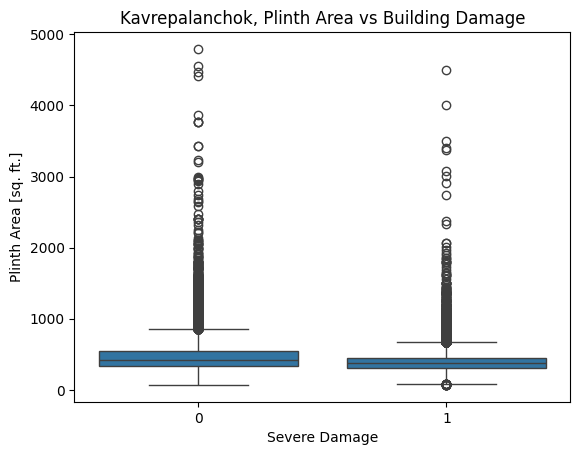

In [22]:
# Create boxplot
sns.boxplot(x="severe_damage",y="plinth_area_sq_ft",data=df)
# Label axes
plt.xlabel("Severe Damage")
plt.ylabel("Plinth Area [sq. ft.]")
plt.title("Kavrepalanchok, Plinth Area vs Building Damage")
# Don't delete the code below 👇
plt.show()

In [23]:
roof_pivot = pd.pivot_table(df,index="roof_type",values="severe_damage",aggfunc=np.mean).sort_values(by="severe_damage")
roof_pivot

,severe_damage
roof_type,
RCC/RB/RBC,0.040715
Bamboo/Timber-Heavy roof,0.569477
Bamboo/Timber-Light roof,0.604842


In [24]:
target = 'severe_damage'
X = df.drop(columns=target)
y = df[target]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (76533, 11)
y shape: (76533,)


In [25]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (61226, 11)
y_train shape: (61226,)
X_val shape: (15307, 11)
y_val shape: (15307,)


In [26]:
acc_baseline = acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.55


In [27]:
#Create a model model_lr that uses logistic regression to predict building damage. Be sure to include an appropriate encoder for categorical features.
model_lr = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression(max_iter=10000)
)
# Fit model to training data
model_lr.fit(X_train, y_train);

In [28]:
#Calculate training and validation accuracy score for model_lr.
lr_train_acc = accuracy_score(y_train,model_lr.predict(X_train))
lr_val_acc = model_lr.score(X_val,y_val)

print("Logistic Regression, Training Accuracy Score:", lr_train_acc)
print("Logistic Regression, Validation Accuracy Score:", lr_val_acc)

Logistic Regression, Training Accuracy Score: 0.6518472544343906
Logistic Regression, Validation Accuracy Score: 0.6528385705886196


Perhaps a decision tree model will perform better than logistic regression, but what's the best hyperparameter value for max_depth? Create a for loop to train and evaluate the model model_dt at all depths from 1 to 15

In [29]:
depth_hyperparams = range(1, 16)
training_acc = []
validation_acc = []
for d in depth_hyperparams:
    model_dt = make_pipeline(
        OrdinalEncoder(), 
        DecisionTreeClassifier(max_depth=d,random_state=42)
    )
    model_dt.fit(X_train, y_train)    
    training_acc.append(model_dt.score(X_train,y_train))
    validation_acc.append(model_dt.score(X_val, y_val))

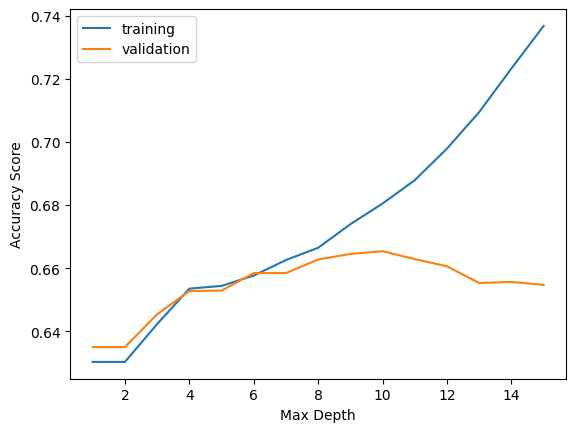

In [30]:
#  Using the values in training_acc and validation_acc, plot the validation curve for model_dt
# Plot `depth_hyperparams`, `training_acc`
plt.plot(depth_hyperparams, training_acc,label="training")
plt.plot(depth_hyperparams, validation_acc,label="validation")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.legend()
# Don't delete the code below 👇
plt.show()

In [31]:
#Build and train a new decision tree model final_model_dt, using the value for max_depth that yielded the best validation accuracy score in your plot above
final_model_dt = make_pipeline(
        OrdinalEncoder(), 
        DecisionTreeClassifier(max_depth=10,random_state=42)
    )
final_model_dt.fit(X_train, y_train)    


Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(cols=['land_surface_condition',
                                      'foundation_type', 'roof_type',
                                      'ground_floor_type', 'other_floor_type',
                                      'position', 'plan_configuration',
                                      'superstructure'],
                                mapping=[{'col': 'land_surface_condition',
                                          'data_type': dtype('O'),
                                          'mapping': Flat              1
Moderate slope    2
Steep slope       3
NaN              -2
dtype: int64},
                                         {'col': 'foundation_type',
                                          'dat...
Building with Central Courtyard     9
H-shape                            10
NaN                                -2
dtype: int64},
                                         {'col': 'superstructure',
                                          'data_type': dtype('O'),
                                          'mapping': Stone, mud mortar        1
Adobe/mud                2
Brick, cement mortar     3
RC, engineered           4
Brick, mud mortar        5
Stone, cement mortar     6
RC, non-engineered       7
Timber                   8
Other                    9
Bamboo                  10
Stone                   11
NaN                     -2
dtype: int64}])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=10, random_state=42))])

In [34]:
X_test = pd.read_csv("data/kavrepalanchok_test_features.csv", index_col="b_id")
y_test_pred = final_model_dt.predict(X_test)
y_test_pred[:5]

array([1, 1, 1, 1, 0])

In [35]:
#Communicate Results
#What are the most important features for final_model_dt? Create a Series Gini feat_imp
features = X_train.columns
importances = final_model_dt.named_steps["decisiontreeclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()
feat_imp.head()

plan_configuration        0.004189
land_surface_condition    0.008599
foundation_type           0.009967
position                  0.011795
ground_floor_type         0.013521
dtype: float64

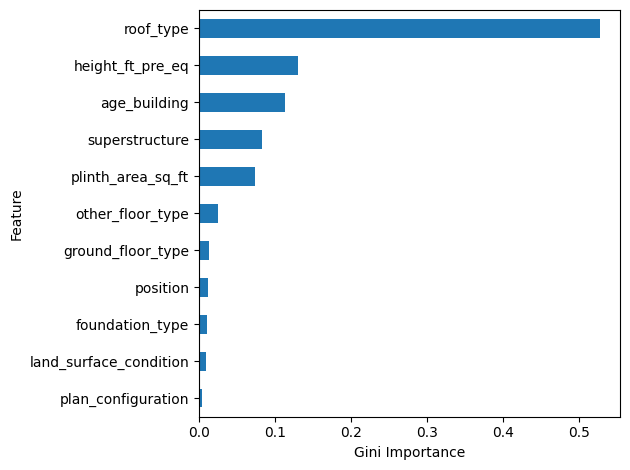

In [36]:
# Create horizontal bar chart of feature importances
feat_imp.plot(kind="barh")
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
# Don't delete the code below 👇
plt.tight_layout()
plt.show()